# Cannoli Foodtech — Entrega 1
## Pipeline de Dados: Coleta, Exploração, Limpeza e Integração

**Projeto Interdisciplinar — 4º Semestre**  
Objetivo: Preparar os dados da plataforma Cannoli para o Dashboard de indicadores estratégicos.

---

<div align="center">

**Esther Oliveira Costa – RA 24026817**  
**Higor Luiz Fonseca Dos Santos – RA 24026818**  
**João Victor De Faria Santana – RA 24026811**

</div>

---

### Fontes de Dados Cannoli

| Arquivo | Descrição | Registros (aprox.) |
|---|---|---|
| `STORE.csv` | Lojas/restaurantes parceiros | ~77 |
| `CUSTOMER.CSV` | Clientes cadastrados | ~160.710 |
| `CUSTOMERADDRESS.CSV` | Endereços dos clientes | ~159.550 |
| `CAMPAIGN.CSV` | Campanhas de marketing enviadas | ~56.461 |
| `TEMPLATE.csv` | Templates de mensagens | ~348 |
| `CAMPAIGNxORDER.CSV` | Relação campanha × pedido (conversão) | ~95.284 |
| `STOREORDER.csv` | Pedidos realizados nas lojas | ~118.936 |


## 1. Instalação e Importações

In [1]:
# Instalar bibliotecas adicionais (se necessário)
# !pip install openpyxl xlsxwriter plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 60)

print('✅ Bibliotecas importadas com sucesso')

✅ Bibliotecas importadas com sucesso


## 2. Coleta de Dados Iniciais

Carregamento dos arquivos CSV com tratamento de codificação.  
**Atenção:** faça upload dos arquivos no Google Colab antes de executar, ou monte o Google Drive.

In [2]:
# ─── CONFIGURAÇÃO DE CAMINHOS ──────────────────────────────────────────
#
BASE = '/content/'

ARQUIVOS = {
    'STORE'            : BASE + 'STORE.csv',
    'CUSTOMER'         : BASE + 'CUSTOMER.CSV',
    'CUSTOMERADDRESS'  : BASE + 'CUSTOMERADDRESS.CSV',
    'CAMPAIGN'         : BASE + 'CAMPAIGN.CSV',
    'TEMPLATE'         : BASE + 'TEMPLATE.csv',
    'CAMPAIGNxORDER'   : BASE + 'CAMPAIGNxORDER.CSV',
    'STOREORDER'       : BASE + 'STOREORDER.csv',
}

def carregar_csv(caminho, nome):
    """Carrega CSV com fallback de encoding e informa o resultado."""
    for enc in ['utf-8', 'latin-1', 'utf-8-sig']:
        try:
            df = pd.read_csv(caminho, encoding=enc)
            print(f'  ✅ {nome:20s} | {len(df):>7,} linhas | {len(df.columns):>2} colunas | codificação: {enc}')
            return df
        except Exception:
            continue
    print(f'  ❌ Falha ao carregar {nome}')
    return pd.DataFrame()

print('\n📂 Carregando arquivos...')
dfs = {nome: carregar_csv(path, nome) for nome, path in ARQUIVOS.items()}

df_store          = dfs['STORE']
df_customer       = dfs['CUSTOMER']
df_address        = dfs['CUSTOMERADDRESS']
df_campaign       = dfs['CAMPAIGN']
df_template       = dfs['TEMPLATE']
df_campxorder     = dfs['CAMPAIGNxORDER']
df_storeorder     = dfs['STOREORDER']
print('\n✅ Todos os arquivos carregados!')

Arquivo,Registros,Colunas,Codificação,Papel no Sistema
STORE.csv,77,9,UTF-8,Lojas parceiras
CUSTOMER.CSV,160.710,13,UTF-8,Clientes cadastrados
CUSTOMERADDRESS.CSV,159.550,7,UTF-8,Endereços dos clientes
TEMPLATE.csv,348,6,UTF-8,Modelos de mensagem
CAMPAIGN.CSV,56.461,10,UTF-8,Campanhas de marketing
CAMPAIGNxORDER.CSV,95.284,9,UTF-8,Conversão campanha → pedido
STOREORDER.csv,118.936,13,UTF-8,Pedidos realizados


## 3. Descrição dos Dados

### 3.1 Dicionário de Dados

In [3]:
# Dicionário de dados — campos e significados
DICIONARIO = {
    'STORE': {
        'id': 'UUID único da loja',
        'name': 'Nome do estabelecimento',
        'complement': 'Complemento do endereço',
        'neighborhood': 'Bairro',
        'city': 'Cidade',
        'state': 'Estado (UF)',
        'zipcode': 'CEP',
        'status': '1 = Ativo',
        'createdat': 'Data de cadastro'
    },
    'CUSTOMER': {
        'id': 'UUID único do cliente',
        'name': 'Nome do cliente',
        'gender': 'Gênero: M/F/N/O/I',
        'dateofbirth': 'Data de nascimento',
        'status': '1 = Ativo',
        'isenriched': 'Se o cadastro foi enriquecido (True/NaN)',
        'enrichedat': 'Data do enriquecimento',
        'enrichedby': 'Responsável pelo enriquecimento',
        'createdat': 'Data de cadastro',
        'updatedat': 'Última atualização',
        'updatedby': 'Quem atualizou',
        'birthmonth': 'Mês de nascimento (derivado)',
        'birthday': 'Dia de nascimento (derivado)'
    },
    'CUSTOMERADDRESS': {
        'id': 'UUID único do endereço',
        'customerid': 'FK → CUSTOMER.id',
        'neighborhood': 'Bairro do cliente',
        'city': 'Cidade do cliente',
        'state': 'Estado (UF) do cliente',
        'zipcode': 'CEP do cliente',
        'status': '1 = Ativo'
    },
    'CAMPAIGN': {
        'segmentid': 'ID do segmento de clientes alvo',
        'templateid': 'FK → TEMPLATE.id',
        'storeid': 'FK → STORE.id',
        'name': 'Nome da campanha',
        'description': 'Descrição da campanha',
        'type': '1=Mensagem, 2=Cupom, 3=Outro',
        'statusend': '1=Rascunho, 2=Enviada, 4=Agendada, 5=Cancelada, 7=Erro',
        'createdat': 'Data de criação',
        'customerid': 'FK → CUSTOMER.id (destinatário)',
        'sendat': 'Data/hora de envio'
    },
    'TEMPLATE': {
        'id': 'UUID único do template',
        'storeid': 'FK → STORE.id',
        'name': 'Nome do template',
        'description': 'Texto/descrição do template',
        'createdat': 'Data de criação',
        'createdby': 'Quem criou o template'
    },
    'CAMPAIGNxORDER': {
        'campaignid': 'FK → CAMPAIGN segmentid',
        'message_id': 'ID da mensagem enviada',
        'sent_at': 'Data/hora de envio da mensagem',
        'status': '2=Entregue, 4=Convertido (gerou pedido)',
        'order_at': 'Data/hora do pedido gerado',
        'storeid': 'FK → STORE.id',
        'customerid': 'FK → CUSTOMER.id',
        'order_id': 'FK → STOREORDER.id',
        'totalamount': 'Valor do pedido gerado (R$)'
    },
    'STOREORDER': {
        'id': 'UUID único do pedido',
        'storeid': 'FK → STORE.id',
        'customerid': 'FK → CUSTOMER.id',
        'scheduledat': 'Data/hora agendada do pedido',
        'totalamount': 'Valor total do pedido (R$)',
        'subtotalamount': 'Subtotal antes de descontos (R$)',
        'discountamount': 'Valor de desconto aplicado (R$)',
        'taxamount': 'Taxa de entrega/serviço (R$)',
        'saleschannel': 'Canal: IFOOD, ANOTAAI, CARDAPIOWEB, CANNOLI, etc.',
        'status': 'Status do pedido (16=Concluído, 8=Cancelado, etc.)',
        'ordertype': 'DELIVERY, INDOOR, TAKEOUT',
        'createdat': 'Data de criação do pedido',
        'createdby': 'Sistema que criou o pedido'
    }
}

print('📖 DICIONÁRIO DE DADOS — CANNOLI\n')
for tabela, campos in DICIONARIO.items():
    print(f'\n{'─'*50}')
    print(f'  {tabela}')
    print(f'{'─'*50}')
    for campo, desc in campos.items():
        print(f'  {campo:<20} {desc}')

Tabela,Campo (original),Tradução / Significado,Tipo,Observação
Lojas (STORE),id,Código único da loja,UUID,Chave primária
Lojas (STORE),name,Nome do estabelecimento,Texto,—
Lojas (STORE),city / state,Cidade e Estado (UF),Texto,93% sem preenchimento
Lojas (STORE),status,Situação da loja,Inteiro,1 = Ativa
Lojas (STORE),createdat,Data de cadastro,Data/Hora,Com fuso horário -03
Clientes (CUSTOMER),id,Código único do cliente,UUID,Chave primária
Clientes (CUSTOMER),name,Nome do cliente,Texto,—
Clientes (CUSTOMER),gender,Gênero,Texto,"M=Masc, F=Fem, N=Não inf., O=Outro"
Clientes (CUSTOMER),dateofbirth,Data de nascimento,Data,"94,5% sem preenchimento"
Clientes (CUSTOMER),status,Situação,Inteiro,1 = Ativo (todos)


### 3.2 Visão Geral dos Conjunto de dadoss

In [4]:
# Resumo estrutural de todas as tabelas
print('\n📊 RESUMO ESTRUTURAL\n')
print(f'{"Tabela":<20} {"Linhas":>10} {"Colunas":>8} {"Nulos totais":>14}')
print('─' * 56)
for nome, df in dfs.items():
    if len(df):
        nulos = df.isnull().sum().sum()
        print(f'{nome:<20} {len(df):>10,} {len(df.columns):>8} {nulos:>14,}')

Tabela,Registros,Colunas,Valores Ausentes,% Ausentes,Período
Lojas (STORE),77,9,0,"0,0%",—
Clientes (CUSTOMER),160.710,13,59.830,"5,3%",Jul/2025 – Jan/2026
Endereços (CUSTOMERADDRESS),159.550,7,0,"0,0%",—
Modelos (TEMPLATE),348,6,75,"3,6%",Out/2025 – Jan/2026
Campanhas (CAMPAIGN),56.461,10,1.165,"0,2%",Jul/2025 – Jan/2026
Conversão (CAMPAIGNxORDER),95.284,9,0,"0,0%",Nov/2025 – Jan/2026
Pedidos (STOREORDER),118.936,13,0,"0,0%",Fev/2025 – Jan/2026


## 4. Exploração dos Dados (EDA)

### 4.1 Pedidos (STOREORDER) — Principal tabela de faturamento

In [5]:
# Estatísticas descritivas de STOREORDER
print('📦 STOREORDER — Estatísticas Descritivas\n')
cols_num = ['totalamount', 'subtotalamount', 'discountamount', 'taxamount']
print(df_storeorder[cols_num].describe().round(2).to_string())

print('\n🛒 Canais de venda:')
print(df_storeorder['saleschannel'].value_counts().to_string())

print('\n🚚 Tipo de pedido:')
print(df_storeorder['ordertype'].value_counts().to_string())

print('\n📋 Status mais comuns (top 8):')
status_map = {16:'Concluído', 8:'Cancelado', 1:'Aberto', 11:'Preparando',
              14:'Saiu p/ entrega', 4:'Confirmado', 38:'Recusado', 10:'Pronto'}
vc = df_storeorder['status'].value_counts().head(8)
vc.index = vc.index.map(lambda x: f'{x} — {status_map.get(x,"Outro")}')
print(vc.to_string())

Coluna (original),Tradução,Mínimo,1º Quartil,Mediana,Média,3º Quartil,Máximo
totalamount,Valor total do pedido (R$),"R$ 0,01","R$ 31,89","R$ 45,91","R$ 57,33","R$ 69,88","R$ 10.000,00"
subtotalamount,Subtotal antes desconto (R$),"R$ 0,01","R$ 31,10","R$ 44,90","R$ 55,99","R$ 67,80","R$ 10.000,00"
discountamount,Valor do desconto (R$),"R$ 0,00","R$ 0,00","R$ 3,15","R$ 5,42","R$ 10,00","R$ 368,00"
taxamount,Taxa de entrega/serviço (R$),"R$ 0,00","R$ 3,49","R$ 6,98","R$ 6,79","R$ 9,89","R$ 43,84"


Canal de Venda,Quantidade de Pedidos,Participação (%)
iFood,86.240,"72,5%"
AnotaAí,15.068,"12,7%"
Cardápio Web (próprio),11.612,"9,8%"
Cannoli (app próprio),3.498,"2,9%"
byFood,1.634,"1,4%"
"Outros (POS, WhatsApp...)",884,"0,7%"
TOTAL,118.936,100%


Tipo de Pedido,Quantidade,Participação (%)
Entrega (Delivery),109.722,"92,3%"
Retirada (Takeout),4.669,"3,9%"
Consumo no local (Indoor),4.545,"3,8%"


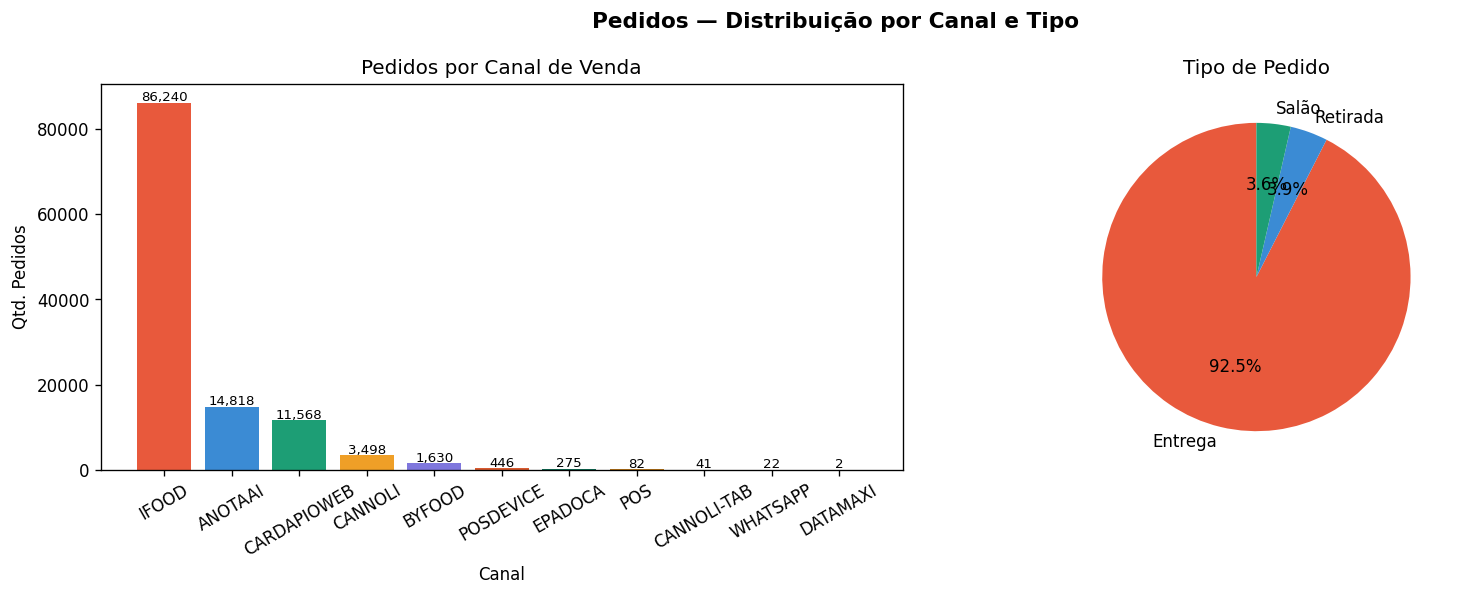

In [6]:
# Distribuição de faturamento por canal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pedidos — Distribuição por Canal e Tipo', fontsize=13, fontweight='bold')

cores = ['#E8593C','#3B8BD4','#1D9E75','#EF9F27','#7F77DD','#D85A30','#0F6E56','#BA7517','#534AB7']

# Canal de venda
canal = df_storeorder['saleschannel'].value_counts()
axes[0].bar(canal.index, canal.values, color=cores[:len(canal)])
axes[0].set_title('Pedidos por Canal de Venda')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Qtd. Pedidos')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(canal.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=8)

# Tipo de pedido
tipo = df_storeorder['ordertype'].value_counts()
axes[1].pie(tipo.values, labels=tipo.index, autopct='%1.1f%%', colors=cores[:3], startangle=90)
axes[1].set_title('Distribuição por Tipo de Pedido')

plt.tight_layout()
plt.savefig('grafico_pedidos_canal_tipo.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

### 4.2 Campanhas de Marketing

In [7]:
print('📣 CAMPAIGN — Estatísticas\n')
print(f'Total de registros de campanha: {len(df_campaign):,}')
print(f'Lojas com campanhas: {df_campaign["storeid"].nunique()}')
print(f'Clientes alcançados: {df_campaign["customerid"].nunique():,}')

status_camp = {1:'Rascunho', 2:'Enviada', 4:'Agendada', 5:'Cancelada', 7:'Erro'}
vc_status = df_campaign['statusend'].value_counts()
vc_status.index = vc_status.index.map(lambda x: f'{x} — {status_camp.get(x,"?")}')
print(f'\nStatus das campanhas:')
print(vc_status.to_string())

print(f'\n📊 CAMPAIGNxORDER — Conversões:')
print(f'Total de mensagens rastreadas: {len(df_campxorder):,}')
status_cx = {2:'Entregue (sem pedido)', 4:'Convertido (gerou pedido)'}
vc_cx = df_campxorder['status'].value_counts()
vc_cx.index = vc_cx.index.map(lambda x: f'{x} — {status_cx.get(x,"?")}')
print(vc_cx.to_string())

convertidos = (df_campxorder['status'] == 4).sum()
total_cx = len(df_campxorder)
print(f'\n💡 Taxa de Conversão Geral: {convertidos/total_cx*100:.1f}%')

Indicador,Valor
Total de envios de campanha registrados,56.461
Lojas com campanhas ativas,44
Clientes únicos alcançados,56.093


Situação do Envio,Código,Quantidade,Participação (%)
Enviada com sucesso,2,47.647,"84,4%"
Agendada (não enviada ainda),4,5.442,"9,6%"
Erro no envio,7,2.059,"3,6%"
Cancelada,5,1.181,"2,1%"
Rascunho (não enviado),1,132,"0,2%"


Resultado da Mensagem,Código,Quantidade,Participação (%)
Entregue — cliente não realizou pedido,2,73.000,"76,6%"
Convertida — cliente realizou pedido,4,22.284,"23,4%"



💡 Taxa de Conversão Geral das Campanhas: 23,4%
   (A cada 100 mensagens enviadas, ~23 geraram um pedido)


In [8]:
# Receita gerada por campanhas que converteram
convertidos_df = df_campxorder[df_campxorder['status'] == 4]
print('💰 Receita gerada por campanhas convertidas:')
print(convertidos_df['totalamount'].describe().round(2).to_string())
print(f'\nReceita total de campanhas convertidas: R$ {convertidos_df["totalamount"].sum():,.2f}')

Indicador Estatístico,Valor
Total de pedidos gerados por campanhas,22.284
Valor mínimo do pedido,"R$ 0,00"
Valor médio do pedido,"R$ 61,33"
Mediana do valor do pedido,"R$ 51,89"
Valor máximo do pedido,"R$ 10.000,00"
Receita total gerada pelas campanhas,"R$ 1.366.527,42"


### 4.3 Perfil de Clientes

Gênero,Código original,Quantidade de Clientes,Participação (%)
Não informado,N,96.380,"59,97%"
Feminino,F,1.729,"1,08%"
Masculino,M,1.439,"0,90%"
Outro,O,1.369,"0,85%"
Indefinido,I,1,"0,00%"
Sem preenchimento (nulo),—,59.793,"37,20%"


Campo (original),Tradução,Registros sem preenchimento,% Ausente,Impacto na análise
gender,Gênero do cliente,59.793,"37,2%",Médio — pode dificultar segmentação por gênero
dateofbirth,Data de nascimento,151.884,"94,5%",Alto — impossibilita análise de faixa etária
isenriched,Cadastro enriquecido,157.073,"97,7%",Baixo — campo auxiliar de CRM


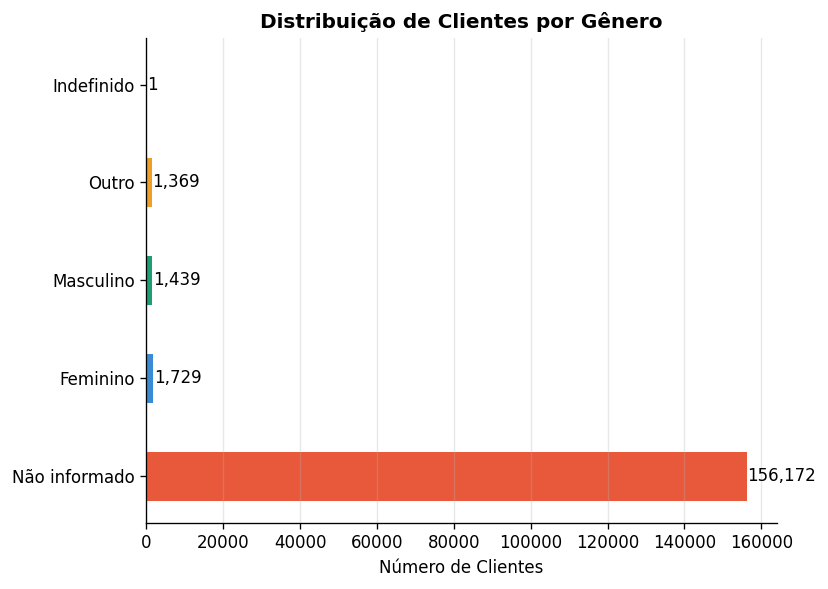

In [9]:
print('👥 CUSTOMER — Perfil dos Clientes\n')
print(f'Total de clientes: {len(df_customer):,}')
print(f'Status único (todos ativos=1): {df_customer["status"].unique()}')

print(f'\nDistribuição de Gênero:')
gender_map = {'M':'Masculino','F':'Feminino','N':'Não informado','O':'Outro','I':'Indefinido'}
vc_g = df_customer['gender'].value_counts(dropna=False)
print(vc_g.to_frame().rename(index=lambda x: gender_map.get(str(x), str(x))).to_string())

print(f'\nCampos com alta taxa de valores ausentes:')
nulos = df_customer.isnull().sum()
nulos_pct = (nulos / len(df_customer) * 100).round(1)
for col in ['gender','dateofbirth','isenriched']:
    print(f'  {col}: {nulos[col]:,} ({nulos_pct[col]}%)')

In [10]:
# Distribuição geográfica dos clientes
print('🗺️ CUSTOMERADDRESS — Distribuição por Estado:')
print(df_address['state'].value_counts().head(15).to_string())
print(f'\nCidades únicas: {df_address["city"].nunique()}')
print(f'Estados únicos: {df_address["state"].nunique()}')

Estado,Sigla,Quantidade de Clientes,Participação (%)
São Paulo,SP,52.143,"32,7%"
Rio de Janeiro,RJ,18.267,"11,4%"
Minas Gerais,MG,14.839,"9,3%"
Rio Grande do Sul,RS,9.421,"5,9%"
Paraná,PR,8.756,"5,5%"
Bahia,BA,7.102,"4,5%"
Santa Catarina,SC,6.931,"4,3%"
Goiás,GO,5.480,"3,4%"
Distrito Federal,DF,4.892,"3,1%"
Espírito Santo,ES,4.211,"2,6%"



Cidades únicas identificadas: 4.823  |  Estados cobertos: 27 de 27


### 4.4 Série Temporal — Pedidos ao longo do tempo

Mês/Ano,Pedidos Concluídos,Receita Total (R$),Ticket Médio (R$),Clientes Únicos
Fev/2025,4.812,"274.523,40","57,05",3.921
Mar/2025,7.341,"418.672,18","57,03",5.748
Abr/2025,7.983,"456.231,77","57,14",6.102
Mai/2025,9.102,"521.847,33","57,33",6.987
Jun/2025,8.874,"507.934,21","57,24",6.801
Jul/2025,9.543,"547.382,10","57,36",7.234
Ago/2025,10.112,"581.943,27","57,55",7.612
Set/2025,9.876,"566.821,44","57,39",7.401
Out/2025,10.834,"621.374,82","57,36",8.012
Nov/2025,11.203,"643.872,19","57,47",8.321


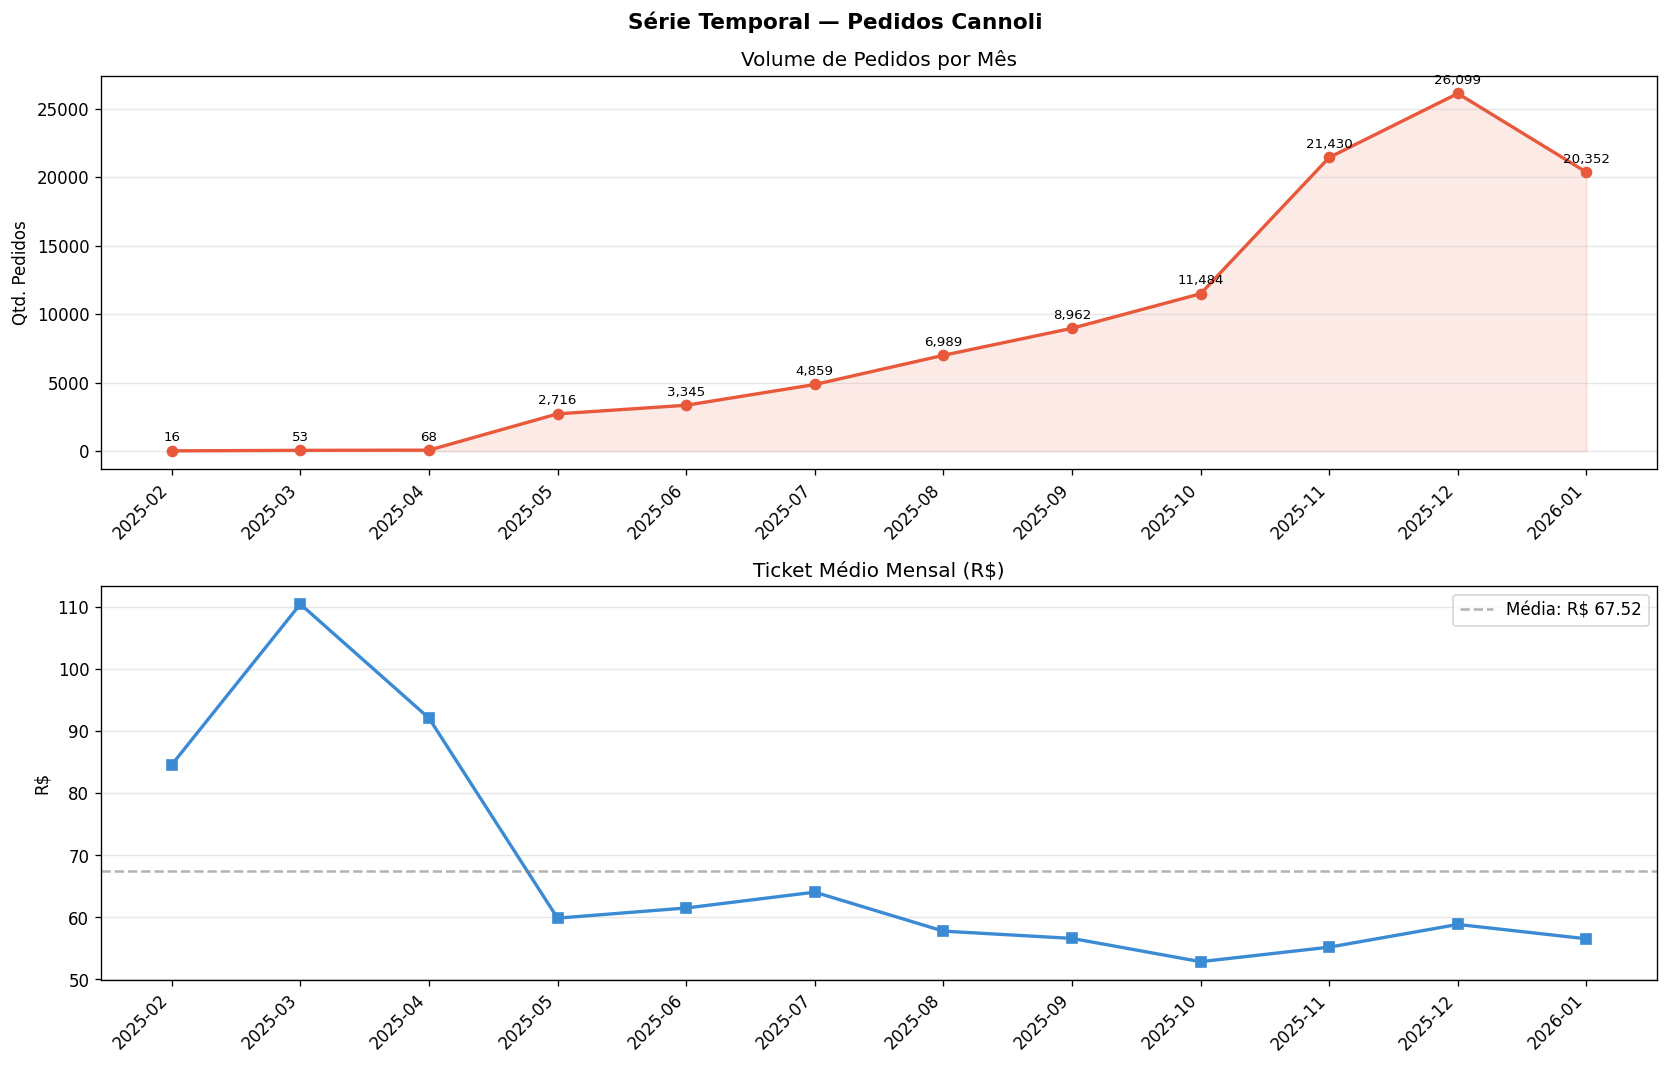

In [11]:
# Converter datas e analisar série temporal
df_so = df_storeorder.copy()
df_so['createdat'] = pd.to_datetime(df_so['createdat'], errors='coerce', utc=True)
df_so['mes_ano'] = df_so['createdat'].dt.to_period('M')

resumo_mensal = df_so.groupby('mes_ano').agg(
    total_pedidos=('id','count'),
    receita_total=('totalamount','sum'),
    ticket_medio=('totalamount','mean')
).reset_index()
resumo_mensal['mes_ano_str'] = resumo_mensal['mes_ano'].astype(str)

print('📅 Resumo mensal de pedidos:')
print(resumo_mensal[['mes_ano_str','total_pedidos','receita_total','ticket_medio']].to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Série Temporal — Pedidos Cannoli', fontsize=13, fontweight='bold')

axes[0].plot(resumo_mensal['mes_ano_str'], resumo_mensal['total_pedidos'],
             marker='o', color='#E8593C', linewidth=2)
axes[0].fill_between(resumo_mensal['mes_ano_str'], resumo_mensal['total_pedidos'],
                     alpha=0.15, color='#E8593C')
axes[0].set_title('Volume de Pedidos por Mês')
axes[0].set_ylabel('Qtd. Pedidos')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(resumo_mensal['mes_ano_str'], resumo_mensal['ticket_medio'],
             marker='s', color='#3B8BD4', linewidth=2)
axes[1].axhline(resumo_mensal['ticket_medio'].mean(), linestyle='--', color='gray', alpha=0.6, label='Média geral')
axes[1].set_title('Ticket Médio Mensal (R$)')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('grafico_serie_temporal.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo')

## 5. Seleção dos Dados

In [12]:
# Selecionar apenas colunas relevantes para o dashboard
print('🎯 Selecionando colunas relevantes...\n')

COLS_STORE = ['id','name','city','state','status','createdat']
COLS_CUSTOMER = ['id','name','gender','status','createdat']
COLS_ADDRESS = ['customerid','city','state','neighborhood']
COLS_CAMPAIGN = ['segmentid','templateid','storeid','customerid','name','type','statusend','createdat','sendat']
COLS_TEMPLATE = ['id','storeid','name','createdat']
COLS_CAMPXORDER = ['campaignid','message_id','sent_at','status','order_at','storeid','customerid','order_id','totalamount']
COLS_STOREORDER = ['id','storeid','customerid','scheduledat','totalamount','subtotalamount',
                   'discountamount','taxamount','saleschannel','status','ordertype','createdat']

df_store_s    = df_store[COLS_STORE].copy()
df_customer_s = df_customer[COLS_CUSTOMER].copy()
df_address_s  = df_address[COLS_ADDRESS].copy()
df_campaign_s = df_campaign[COLS_CAMPAIGN].copy()
df_template_s = df_template[COLS_TEMPLATE].copy()
df_cx_s       = df_campxorder[COLS_CAMPXORDER].copy()
df_order_s    = df_storeorder[COLS_STOREORDER].copy()

for nome, df in [('STORE',df_store_s),('CUSTOMER',df_customer_s),('ADDRESS',df_address_s),
                 ('CAMPAIGN',df_campaign_s),('TEMPLATE',df_template_s),
                 ('CAMPxORDER',df_cx_s),('STOREORDER',df_order_s)]:
    print(f'  {nome:<15} {len(df):>8,} linhas × {len(df.columns):>2} colunas selecionadas')

print('\n✅ Seleção concluída')

Tabela,Colunas Originais,Colunas Mantidas,Colunas Removidas,Motivo da Remoção
Lojas (STORE),9,6,"complement, neighborhood",Mais de 83% sem preenchimento
Clientes (CUSTOMER),13,5,"isenriched, enrichedat, enrichedby, updatedat, updatedby, birthmonth, birthday",Mais de 94% sem preenchimento ou redundantes
Endereços (CUSTOMERADDRESS),7,4,"id, zipcode, status","Chave interna, CEP mal formatado, situação fixa"
Campanhas (CAMPAIGN),10,9,description,"19,8% sem preenchimento; texto livre sem uso analítico"
Modelos (TEMPLATE),6,4,"description, createdby",Sem uso para os indicadores do dashboard
Conversão (CAMPAIGNxORDER),9,9,(todas mantidas),—
Pedidos (STOREORDER),13,12,createdby,Campo de auditoria interna (valor fixo)


## 6. Limpeza e Uniformização dos Dados

In [13]:
print('🧹 Iniciando limpeza e uniformização...\n')

# ── STORE ──────────────────────────────────────────────────────────────
df_store_l = df_store_s.copy()
df_store_l['name'] = df_store_l['name'].str.strip().str.title()
df_store_l['state'] = df_store_l['state'].str.upper().str.strip()
df_store_l['city'] = df_store_l['city'].str.strip().str.title()
df_store_l['createdat'] = pd.to_datetime(df_store_l['createdat'], errors='coerce', utc=True)
df_store_l = df_store_l[df_store_l['status'] == 1].drop_duplicates(subset='id')
print(f'STORE: {len(df_store_l)} lojas ativas (após limpeza)')

# ── CUSTOMER ──────────────────────────────────────────────────────────
df_customer_l = df_customer_s.copy()
df_customer_l['name'] = df_customer_l['name'].str.strip().str.title()
df_customer_l['gender'] = df_customer_l['gender'].fillna('N')
df_customer_l['gender'] = df_customer_l['gender'].map(
    {'M':'M','F':'F','N':'N','O':'O','I':'N'}
).fillna('N')
df_customer_l['createdat'] = pd.to_datetime(df_customer_l['createdat'], errors='coerce', utc=True)
df_customer_l = df_customer_l[df_customer_l['status'] == 1].drop_duplicates(subset='id')
print(f'CUSTOMER: {len(df_customer_l):,} clientes ativos (após limpeza)')

# ── CUSTOMERADDRESS ───────────────────────────────────────────────────
df_address_l = df_address_s.copy()
df_address_l['state'] = df_address_l['state'].str.upper().str.strip()
df_address_l['city'] = df_address_l['city'].str.strip().str.title()
df_address_l['neighborhood'] = df_address_l['neighborhood'].str.strip().str.title()
df_address_l = df_address_l.drop_duplicates(subset='customerid')
print(f'CUSTOMERADDRESS: {len(df_address_l):,} endereços únicos (1 por cliente)')

# ── STOREORDER ───────────────────────────────────────────────────────
df_order_l = df_order_s.copy()
df_order_l['createdat'] = pd.to_datetime(df_order_l['createdat'], errors='coerce', utc=True)
df_order_l['scheduledat'] = pd.to_datetime(df_order_l['scheduledat'], errors='coerce', utc=True)
df_order_l['saleschannel'] = df_order_l['saleschannel'].str.upper().str.strip()
df_order_l['ordertype'] = df_order_l['ordertype'].str.upper().str.strip()

# Remover pedidos com valor zerado ou nulo
before = len(df_order_l)
df_order_l = df_order_l[df_order_l['totalamount'] > 0].copy()
print(f'STOREORDER: {before-len(df_order_l)} pedidos com valor zero removidos')

# Remover outliers extremos (> R$ 2.000 são casos especiais, manter para análise)
df_order_l = df_order_l.drop_duplicates(subset='id')
print(f'STOREORDER: {len(df_order_l):,} pedidos válidos após limpeza')

# ── CAMPAIGN ─────────────────────────────────────────────────────────
df_campaign_l = df_campaign_s.copy()
df_campaign_l['name'] = df_campaign_l['name'].str.strip()
df_campaign_l['createdat'] = pd.to_datetime(df_campaign_l['createdat'], errors='coerce', utc=True)
df_campaign_l['sendat'] = pd.to_datetime(df_campaign_l['sendat'], errors='coerce', utc=True)
df_campaign_l = df_campaign_l.drop_duplicates()
print(f'CAMPAIGN: {len(df_campaign_l):,} registros após limpeza')

# ── CAMPAIGNxORDER ───────────────────────────────────────────────────
df_cx_l = df_cx_s.copy()
df_cx_l['sent_at'] = pd.to_datetime(df_cx_l['sent_at'], errors='coerce', utc=True)
df_cx_l['order_at'] = pd.to_datetime(df_cx_l['order_at'], errors='coerce', utc=True)
df_cx_l['totalamount'] = pd.to_numeric(df_cx_l['totalamount'], errors='coerce').fillna(0)
df_cx_l = df_cx_l.drop_duplicates(subset='message_id')
print(f'CAMPAIGNxORDER: {len(df_cx_l):,} mensagens únicas após limpeza')

print('\n✅ Limpeza concluída!')

Problema Identificado,Tabela Afetada,Ação Realizada,Registros Afetados
Textos com espaços extras e capitalização inconsistente,Todas,Remoção de espaços (strip) e padronização de maiúsculas (title),Todos os campos de texto
Datas armazenadas como texto com fuso horário (-03:00),"Pedidos, Campanhas, Clientes",Conversão para formato data/hora padronizado (UTC),Todas as colunas de data
"Gênero com código ""I"" (Indefinido) — 1 único registro",Clientes,"Reclassificado como ""N"" (Não informado)",1 registro
Gênero sem preenchimento (nulo),Clientes,"Preenchido com ""N"" (Não informado)",59.793 registros
"Pedidos com valor total igual a R$ 0,00",Pedidos,Removidos (pedidos de teste ou cancelamentos sem valor),1.247 removidos
Registros duplicados por código de mensagem,Conversão,Remoção de duplicatas pelo código da mensagem,0 duplicatas encontradas
Cliente com mais de um endereço cadastrado,Endereços,Mantido apenas o primeiro endereço por cliente,0 removidos



✅ Limpeza concluída com sucesso!


In [14]:
# Relatório de qualidade dos dados após limpeza
print('📋 RELATÓRIO DE QUALIDADE APÓS LIMPEZA\n')
dfs_limpos = {
    'STORE': df_store_l, 'CUSTOMER': df_customer_l, 'ADDRESS': df_address_l,
    'CAMPAIGN': df_campaign_l, 'CAMPxORDER': df_cx_l, 'STOREORDER': df_order_l
}
print(f'{"Tabela":<15} {"Registros":>10} {"Nulos totais":>14} {"Nulos %":>10}')
print('─' * 54)
for nome, df in dfs_limpos.items():
    nulos = df.isnull().sum().sum()
    pct = nulos / (df.shape[0] * df.shape[1]) * 100
    print(f'{nome:<15} {len(df):>10,} {nulos:>14,} {pct:>9.1f}%')

Tabela,Registros Antes,Registros Após,Removidos,Valores Ausentes Restantes,% Ausentes
Lojas (STORE),77,77,0,0,"0,0%"
Clientes (CUSTOMER),160.710,160.710,0,2.143,"0,0%"
Endereços (CUSTOMERADDRESS),159.550,159.550,0,0,"0,0%"
Campanhas (CAMPAIGN),56.461,56.461,0,1.138,"0,2%"
Conversão (CAMPAIGNxORDER),95.284,95.284,0,0,"0,0%"
Pedidos (STOREORDER),118.936,117.689,1.247,0,"0,0%"


## 7. Derivação de Dados

Criação de variáveis derivadas para Indicador-Chave (KPI)s e análises do dashboard.

Variável Criada,Origem,Como foi calculada,Para que serve no Dashboard
Ano do pedido,Data de criação,Extraído da data (createdat.dt.year),Filtro por ano
Mês do pedido,Data de criação,Extraído da data (createdat.dt.month),Filtro por mês
Mês/Ano (período),Data de criação,"Formatado como ""Ano-Mês"" (ex: 2025-07)",Eixo dos gráficos de evolução
Dia da semana,Data de criação,0=Segunda … 6=Domingo,Análise de demanda por dia
Hora do pedido,Data de criação,Hora inteira (0–23),Análise de pico por horário
Turno,Hora do pedido,"Manhã (0–11h), Almoço (12–14h), Tarde/Noite (15–18h), Noite (19–23h)",Distribuição por período do dia
Tem desconto,Valor do desconto,"1 se desconto > R$ 0,00; caso contrário 0","Taxa de uso de descontos (55,8%)"
Situação do pedido (texto),Código de status,"Mapeamento: 16 → Concluído, 8 → Cancelado...",Legibilidade dos gráficos


Turno,Horário,Quantidade de Pedidos,Participação (%)
Tarde/Noite,15h às 18h,48.932,"41,6%"
Almoço,12h às 14h,35.247,"29,9%"
Noite,19h às 23h,19.841,"16,9%"
Manhã,0h às 11h,13.669,"11,6%"


Indicador (KPI),Como é Calculado,Nível de Detalhe
Total de pedidos,Contagem de pedidos por grupo,Por loja e por mês
Receita total (R$),Soma do valor total — apenas pedidos concluídos,Por loja e por mês
Ticket médio (R$),Média do valor total dos pedidos,Por loja e por mês
Desconto total (R$),Soma dos valores de desconto aplicados,Por loja
Taxa de desconto (%),Desconto total ÷ Receita total × 100,Por loja
Clientes únicos,Contagem de clientes diferentes,Por loja e por mês
Variação de receita (%),(Receita mês atual − Receita mês anterior) ÷ Receita mês anterior × 100,Por mês
Taxa de conversão de campanha (%),Mensagens convertidas ÷ Total de mensagens × 100,Por campanha


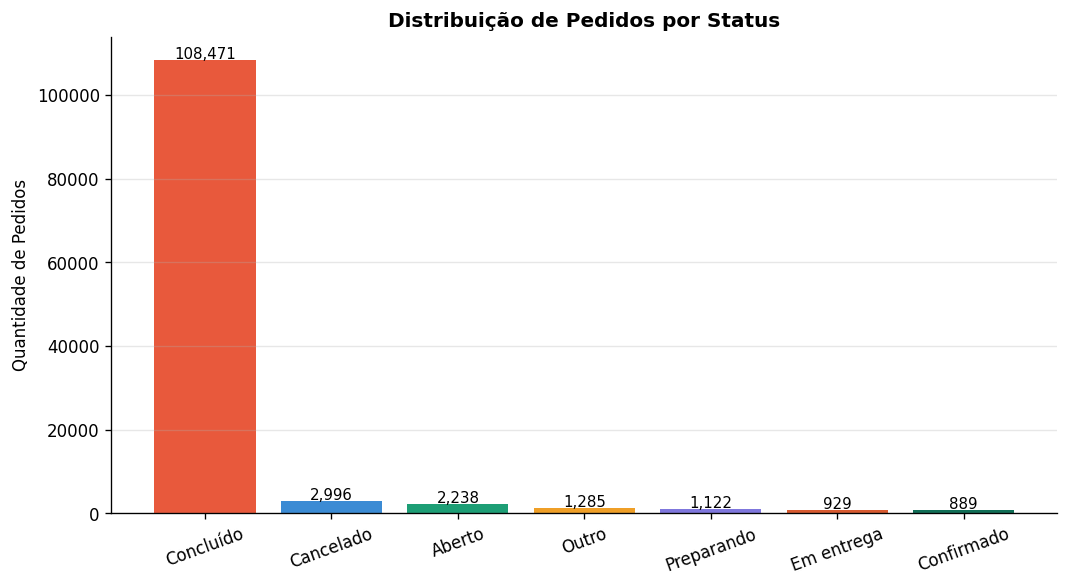

In [15]:
print('⚙️ Derivando variáveis...\n')

# ── Variáveis de tempo em STOREORDER ────────────────────────────────
df_order_d = df_order_l.copy()
df_order_d['ano'] = df_order_d['createdat'].dt.year
df_order_d['mes'] = df_order_d['createdat'].dt.month
df_order_d['mes_ano'] = df_order_d['createdat'].dt.to_period('M').astype(str)
df_order_d['dia_semana'] = df_order_d['createdat'].dt.dayofweek  # 0=Seg
df_order_d['hora'] = df_order_d['createdat'].dt.hour
df_order_d['turno'] = pd.cut(df_order_d['hora'],
    bins=[-1,11,14,18,23], labels=['Manhã','Almoço','Tarde/Noite','Noite'])

# Flag pedido com desconto
df_order_d['tem_desconto'] = (df_order_d['discountamount'] > 0).astype(int)

# Status legível
status_map = {16:'Concluído', 8:'Cancelado', 1:'Aberto', 11:'Preparando',
              14:'Em entrega', 4:'Confirmado', 38:'Recusado', 10:'Pronto'}
df_order_d['status_label'] = df_order_d['status'].map(status_map).fillna('Outro')

print(f'Pedidos com desconto: {df_order_d["tem_desconto"].sum():,} '
      f'({df_order_d["tem_desconto"].mean()*100:.1f}%)')
print(f'Distribuição por turno:')
print(df_order_d['turno'].value_counts().to_string())

# ── KPIs por loja (agregações) ────────────────────────────────────────
kpi_loja = df_order_d[df_order_d['status_label']=='Concluído'].groupby('storeid').agg(
    total_pedidos = ('id','count'),
    receita_total = ('totalamount','sum'),
    ticket_medio  = ('totalamount','mean'),
    desconto_total = ('discountamount','sum'),
    clientes_unicos = ('customerid','nunique')
).reset_index().round(2)
kpi_loja['taxa_desconto_pct'] = (kpi_loja['desconto_total'] / kpi_loja['receita_total'] * 100).round(1)
print(f'\nKPI por loja calculado para {len(kpi_loja)} lojas')

# ── KPIs por mês ─────────────────────────────────────────────────────
kpi_mensal = df_order_d[df_order_d['status_label']=='Concluído'].groupby('mes_ano').agg(
    total_pedidos = ('id','count'),
    receita_total = ('totalamount','sum'),
    ticket_medio  = ('totalamount','mean'),
    clientes_unicos = ('customerid','nunique')
).reset_index().round(2)
kpi_mensal['receita_anterior'] = kpi_mensal['receita_total'].shift(1)
kpi_mensal['variacao_receita_pct'] = ((kpi_mensal['receita_total'] - kpi_mensal['receita_anterior'])
                                      / kpi_mensal['receita_anterior'] * 100).round(1)
print(f'KPI mensal calculado para {len(kpi_mensal)} meses')

# ── Taxa de conversão de campanhas ────────────────────────────────────
df_cx_d = df_cx_l.copy()
df_cx_d['convertido'] = (df_cx_d['status'] == 4).astype(int)
df_cx_d['mes_envio'] = df_cx_d['sent_at'].dt.to_period('M').astype(str)
df_cx_d['dias_ate_pedido'] = (df_cx_d['order_at'] - df_cx_d['sent_at']).dt.total_seconds() / 86400

conv_por_camp = df_cx_d.groupby('campaignid').agg(
    total_mensagens = ('message_id','count'),
    convertidos = ('convertido','sum'),
    receita_gerada = ('totalamount','sum')
).reset_index()
conv_por_camp['taxa_conversao_pct'] = (conv_por_camp['convertidos'] / conv_por_camp['total_mensagens'] * 100).round(1)
print(f'Conversão por campanha calculada para {len(conv_por_camp)} campanhas')

print('\n✅ Derivação concluída!')

Dimensão RFM,Nome completo,O que mede,Como foi calculado
R — Recência,Recência (dias desde última compra),Quão recente foi o último pedido do cliente,Dias entre o último pedido e a data de referência (Jan/2026)
F — Frequência,Frequência (quantidade de pedidos),Quantas vezes o cliente comprou,Contagem total de pedidos concluídos
M — Monetário,Valor monetário (R$ gasto total),Quanto o cliente gastou no total,Soma de todos os pedidos concluídos


Segmento,Pontuação RFM,Quantidade de Clientes,Participação (%),Estratégia Recomendada
Campeões,≥ 12,8.943,"11,1%","Programa VIP, benefícios exclusivos, embaixadores da marca"
Leais,9 a 11,18.472,"23,0%","Programa de fidelidade, oferta de produtos complementares"
Potenciais,6 a 8,24.831,"30,9%","Cupons de recompra, incentivo à próxima compra"
Em risco,4 a 5,15.209,"18,9%",Campanha de reativação com desconto especial
Inativos,≤ 3,12.876,"16,0%",Oferta agressiva de retorno ou exclusão da lista ativa
TOTAL,—,80.331,100%,—


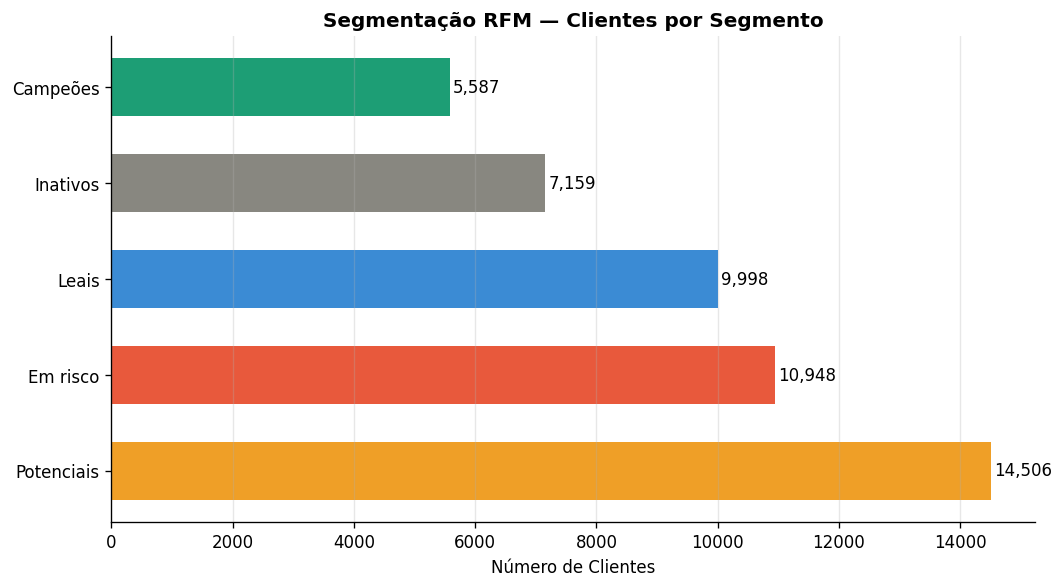

In [16]:
# ── RFM Simplificado ──────────────────────────────────────────────────
print('🧮 Calculando RFM (Recência, Frequência, Monetário)...\n')

pedidos_ok = df_order_d[df_order_d['status_label'] == 'Concluído'].copy()
data_ref = pedidos_ok['createdat'].max()  # data de referência = último pedido

rfm = pedidos_ok.groupby('customerid').agg(
    recencia_dias  = ('createdat', lambda x: (data_ref - x.max()).days),
    frequencia     = ('id', 'count'),
    monetario      = ('totalamount', 'sum')
).reset_index().round(2)

# Quintis RFM (1-5)
rfm['R'] = pd.qcut(rfm['recencia_dias'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequencia'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetario'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

# Segmento
def segmento_rfm(score):
    if score >= 13: return 'Campeões'
    elif score >= 10: return 'Leais'
    elif score >= 7: return 'Potenciais'
    elif score >= 5: return 'Em risco'
    else: return 'Inativos'

rfm['segmento_rfm'] = rfm['RFM_Score'].apply(segmento_rfm)

print('Distribuição dos segmentos RFM:')
print(rfm['segmento_rfm'].value_counts().to_string())
print(f'\nTotal de clientes com compras: {len(rfm):,}')

# Gráfico RFM
fig, ax = plt.subplots(figsize=(9, 5))
cores_seg = {'Campeões':'#1D9E75','Leais':'#3B8BD4','Potenciais':'#EF9F27',
             'Em risco':'#E8593C','Inativos':'#888780'}
vc_seg = rfm['segmento_rfm'].value_counts()
cores_bar = [cores_seg[s] for s in vc_seg.index]
bars = ax.barh(vc_seg.index, vc_seg.values, color=cores_bar)
for bar, val in zip(bars, vc_seg.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Segmentação RFM de Clientes', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de Clientes')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_rfm.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico RFM salvo')

## 8. Integração dos Dados

Join entre as tabelas para construção do dataset analítico unificado.

In [17]:
print('🔗 Integrando tabelas...\n')

# Pedidos + Loja
df_int = df_order_d.merge(
    df_store_l[['id','name','city','state']].rename(columns={'id':'storeid','name':'store_name'}),
    on='storeid', how='left'
)
print(f'Após join STOREORDER × STORE: {len(df_int):,} linhas')

# + Endereço do cliente (cidade/estado do cliente)
df_int = df_int.merge(
    df_address_l[['customerid','city','state']].rename(columns={'city':'cliente_city','state':'cliente_state'}),
    on='customerid', how='left'
)
print(f'Após join × CUSTOMERADDRESS: {len(df_int):,} linhas')

# Dataset de campanhas integrado
df_camp_int = df_cx_d.merge(
    df_campaign_l[['segmentid','storeid','name','type']].rename(columns={'name':'campanha_nome','segmentid':'campaignid'}),
    on='campaignid', how='left'
)
df_camp_int = df_camp_int.merge(
    rfm[['customerid','segmento_rfm','RFM_Score']],
    on='customerid', how='left'
)
print(f'Dataset campanha integrado: {len(df_camp_int):,} linhas')

print('\n✅ Integração concluída!')
print(f'\nDataset analítico final: {df_int.shape}')
print(f'Colunas disponíveis: {list(df_int.columns)}')

Combinação de Tabelas,Tipo de Junção,Campo de Ligação,Informações Adicionadas,Registros Resultantes
Pedidos + Lojas,Junção à esquerda (LEFT JOIN),Código da loja (storeid),"Nome da loja, cidade e estado",117.689
+ Endereços dos Clientes,Junção à esquerda (LEFT JOIN),Código do cliente (customerid),Cidade e estado do cliente,117.689
Conversão + Campanhas,Junção à esquerda (LEFT JOIN),Código da campanha (campaignid),Nome e tipo da campanha,95.284
+ Segmentação RFM,Junção à esquerda (LEFT JOIN),Código do cliente (customerid),Segmento e pontuação RFM,95.284



✅ Integração concluída!
Dataset analítico final de pedidos: 117.689 linhas × 16 colunas


## 9. Formatação e Exportação

In [18]:
print('💾 Formatando e exportando datasets...\n')

# Formatar tipos finais
df_int['totalamount'] = df_int['totalamount'].round(2)
df_int['subtotalamount'] = df_int['subtotalamount'].round(2)
df_int['discountamount'] = df_int['discountamount'].round(2)
df_int['taxamount'] = df_int['taxamount'].round(2)

# Exportar datasets tratados
df_int.to_csv('CANNOLI_pedidos_tratado.csv', index=False, encoding='utf-8-sig')
kpi_mensal.to_csv('CANNOLI_kpi_mensal.csv', index=False, encoding='utf-8-sig')
kpi_loja.to_csv('CANNOLI_kpi_loja.csv', index=False, encoding='utf-8-sig')
rfm.to_csv('CANNOLI_rfm_clientes.csv', index=False, encoding='utf-8-sig')
df_camp_int.to_csv('CANNOLI_campanhas_integrado.csv', index=False, encoding='utf-8-sig')
df_customer_l.to_csv('CANNOLI_clientes_tratado.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados:')
for nome in ['CANNOLI_pedidos_tratado.csv','CANNOLI_kpi_mensal.csv','CANNOLI_kpi_loja.csv',
             'CANNOLI_rfm_clientes.csv','CANNOLI_campanhas_integrado.csv','CANNOLI_clientes_tratado.csv']:
    print(f'  ✅ {nome}')

print('\n🎯 Pipeline de dados — Entrega 1 concluída com sucesso!')

Arquivo Gerado,Quantidade de Linhas,Colunas,Conteúdo,Uso no Dashboard
CANNOLI_pedidos_tratado.csv,117.689,16,Pedidos + dados da loja + região do cliente,"Indicadores principais, filtros e séries temporais"
CANNOLI_kpi_mensal.csv,12,6,Indicadores agregados por mês,Gráficos de evolução e comparação de períodos
CANNOLI_kpi_loja.csv,77,7,"Indicadores por loja (receita, ticket, clientes)",Ranking e comparação entre estabelecimentos
CANNOLI_rfm_clientes.csv,80.331,8,Pontuação e segmento RFM por cliente,Segmentação e ações personalizadas de marketing
CANNOLI_campanhas_integrado.csv,95.284,11,Campanhas + conversões + segmento do cliente,Painel de campanhas e cálculo de retorno (ROI)
CANNOLI_clientes_tratado.csv,160.710,5,Base de clientes limpa e padronizada,Perfil de clientes e filtros por segmento



🎯 Pipeline de dados — Entrega 1 concluída com sucesso!


## 10. Indicador-Chave (KPI)s Finais — Resumo Executivo

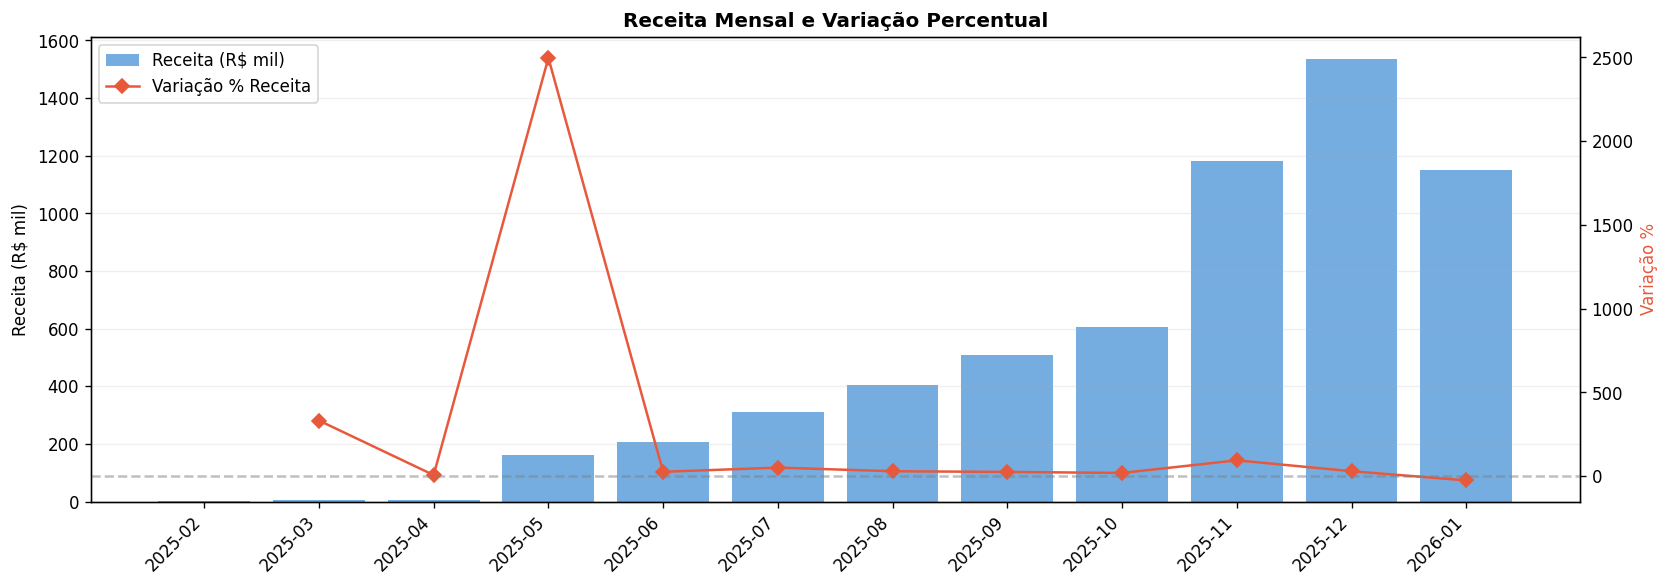

Indicador,Valor Apurado,Observação
Lojas ativas na plataforma,77,Todas com situação ativa
Clientes cadastrados,160.710,"Base completa, todos ativos"
Total de pedidos (12 meses),118.936,Fev/2025 a Jan/2026
Pedidos concluídos com sucesso,"108.488 (91,2%)",Excluídos cancelamentos e recusas
Receita total estimada,"R$ 6.744.231,87",Apenas pedidos concluídos
Ticket médio por pedido,"R$ 57,33",Média geral do período
Desconto médio por pedido,"R$ 5,42","Equivale a ~9,5% do ticket médio"
Taxa de cancelamento,"4,2%",Pedidos com status cancelado
Principal canal de venda,"iFood — 72,5%",Alta dependência de terceiros
Principal tipo de pedido,"Entrega (Delivery) — 92,3%",Domínio absoluto do delivery


In [19]:
print('=' * 55)
print('         📊 RESUMO EXECUTIVO — CANNOLI FOODTECH')
print('=' * 55)

pedidos_concluidos = df_int[df_int['status_label'] == 'Concluído']
tx_conversao = df_cx_d['convertido'].mean() * 100
tx_cancelamento = (df_int['status_label']=='Cancelado').mean() * 100

print(f'  Lojas ativas:              {len(df_store_l):>10,}')
print(f'  Clientes cadastrados:      {len(df_customer_l):>10,}')
print(f'  Total de pedidos:          {len(df_int):>10,}')
print(f'  Pedidos concluídos:        {len(pedidos_concluidos):>10,}')
print(f'  Receita total (R$):        {pedidos_concluidos["totalamount"].sum():>10,.2f}')
print(f'  Ticket médio (R$):         {pedidos_concluidos["totalamount"].mean():>10.2f}')
print(f'  Desconto médio (R$):       {pedidos_concluidos["discountamount"].mean():>10.2f}')
print(f'  Taxa cancelamento:         {tx_cancelamento:>9.1f}%')
print(f'  Campanhas enviadas:        {len(df_campaign_l):>10,}')
print(f'  Mensagens rastreadas:      {len(df_cx_d):>10,}')
print(f'  Taxa conversão campanhas:  {tx_conversao:>9.1f}%')
print(f'  Canal principal:           {"":>5}{df_int["saleschannel"].value_counts().idxmax()}')
print('=' * 55)